# 03 — Exploratory Data Analysis
Story-level exploration of the cleansed stablecoin data: price timelines, landmark depeg events, on-chain flow signals, and macro context.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| **▶ 03** | **EDA** | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 08 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 09 | Final Model (CatBoost) | + `selected_features.json` → `data/models/downside_depeg_catboost.cbm` + `downside_depeg_meta.json` |
| 10 | Threshold & Ops | `data/models/downside_depeg_meta.json` → threshold, alert metrics |
| 11 | LOEO Validation | `data/models/downside_depeg_meta.json` → leave-one-event-out results |

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

Running locally


In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                               # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CLEANSED_DIR = ROOT / "data" / "processed" / "cleansed"

COINS  = ['usdt', 'usdc', 'dai', 'busd', 'ust', 'usde', 'rlusd']
COLORS = {'usdt': '#26A17B', 'usdc': '#2775CA', 'dai': '#F5AC37',
          'busd': '#F0B90B', 'ust':  '#E84142', 'usde': '#9B59B6', 'rlusd': '#00AAE4'}

print(f"Project root:  {ROOT}")
print(f"Cleansed dir:  {CLEANSED_DIR}")

Project root:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Cleansed dir:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/cleansed


## 1. Dataset Overview

In [3]:
rows = []
dfs  = {}
for coin in COINS:
    df = pd.read_parquet(CLEANSED_DIR / f'{coin}_5m.parquet')
    dfs[coin] = df
    rows.append({
        'Coin'        : coin.upper(),
        'Rows'        : f'{len(df):,}',
        'Columns'     : len(df.columns),
        'Start'       : str(df.index.min().date()),
        'End'         : str(df.index.max().date()),
        'Depeg Rate'  : f"{df['depeg'].mean():.2%}",
        'Depeg Hours' : f"{(df['depeg']==1).sum()*5/60:.0f}h",
    })

pd.DataFrame(rows).set_index('Coin').style\
    .set_caption("Cleansed dataset overview")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])

,Rows,Columns,Start,End,Depeg Rate,Depeg Hours
Coin,,,,,,
USDT,"897,936",77,2017-08-17,2026-02-28,9.12%,6822h
USDC,"775,506",89,2018-10-16,2026-02-28,5.59%,3611h
DAI,"828,963",51,2018-04-13,2026-02-28,10.67%,7371h
BUSD,"370,848",46,2019-09-20,2023-03-31,0.28%,85h
UST,"153,961",51,2020-11-23,2022-05-12,5.31%,681h
USDE,"200,928",46,2024-04-02,2026-02-28,0.05%,8h
RLUSD,"96,192",51,2025-04-01,2026-02-28,0.00%,0h


## 2. Price Deviation — All Coins

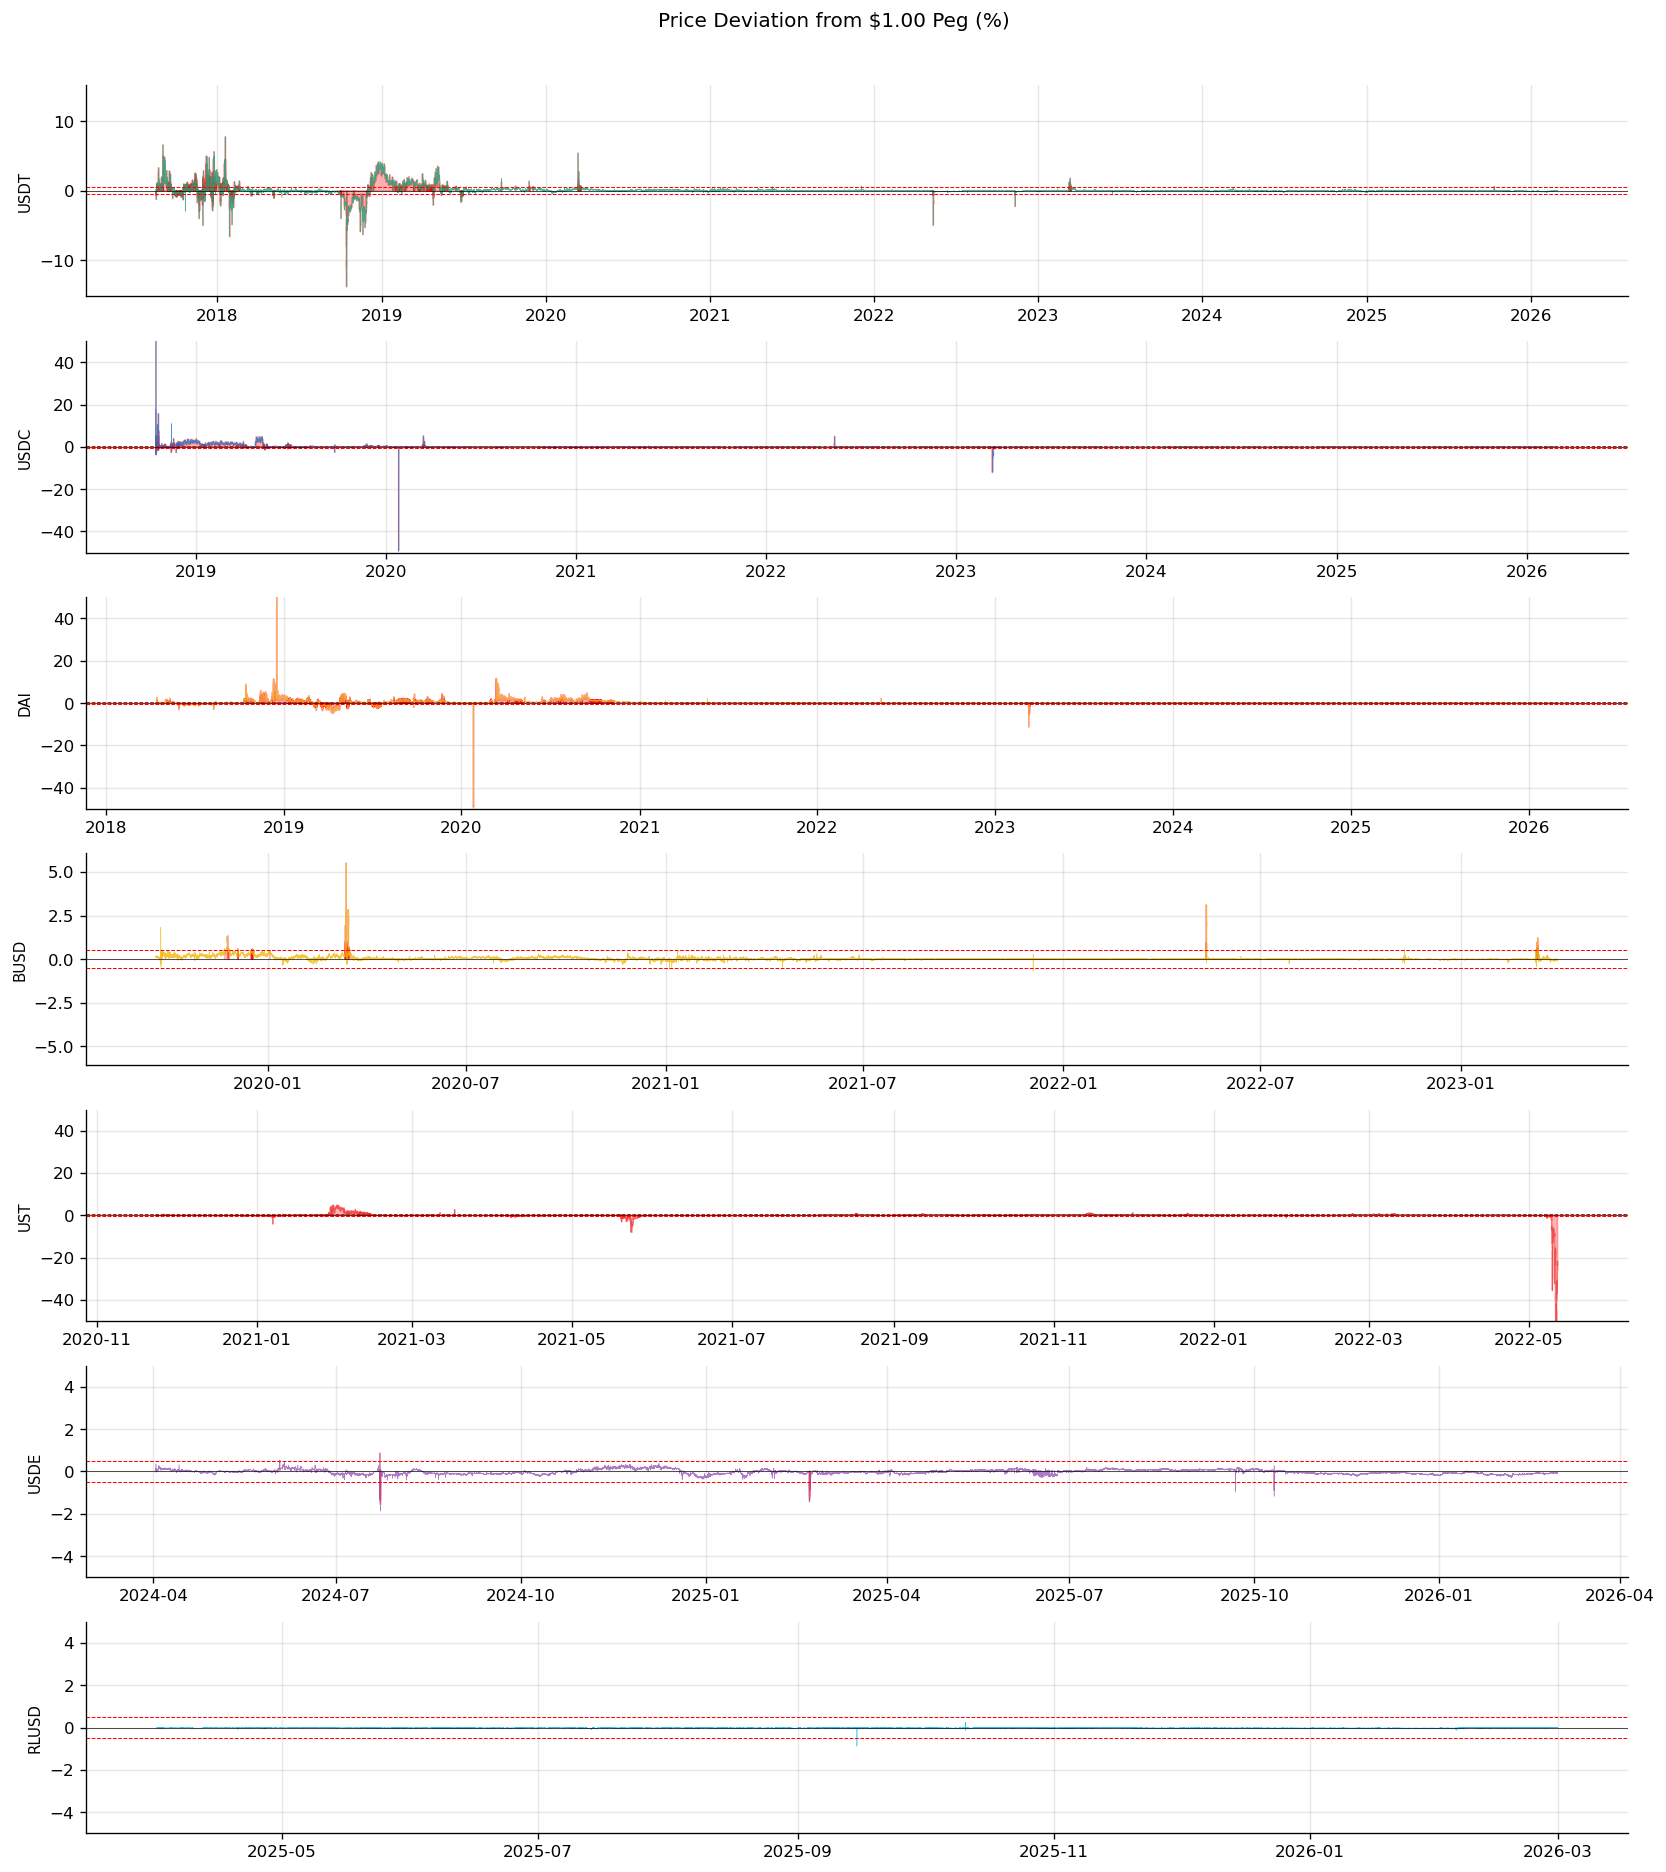

In [4]:
fig, axes = plt.subplots(len(COINS), 1, figsize=(14, 2.2*len(COINS)), sharex=False)

for ax, coin in zip(axes, COINS):
    df    = dfs[coin]
    pct   = df['price_dev'] * 100
    depeg = df['depeg'].fillna(0).astype(float)
    ax.plot(df.index, pct, lw=0.3, color=COLORS[coin], alpha=0.8)
    ax.fill_between(df.index, pct, 0, where=(depeg==1),
                    color='red', alpha=0.3, label='Depeg')
    ax.axhline( 0.5, color='red', lw=0.6, ls='--')
    ax.axhline(-0.5, color='red', lw=0.6, ls='--')
    ax.axhline( 0,   color='black', lw=0.4)
    ax.set_ylabel(coin.upper(), fontsize=9)
    ax.set_ylim(-5, 5)
    ymax = max(abs(pct.min()), abs(pct.max()))
    if ymax > 5:
        ax.set_ylim(-min(ymax*1.1, 50), min(ymax*1.1, 50))

fig.suptitle('Price Deviation from $1.00 Peg (%)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Depeg Rate by Coin

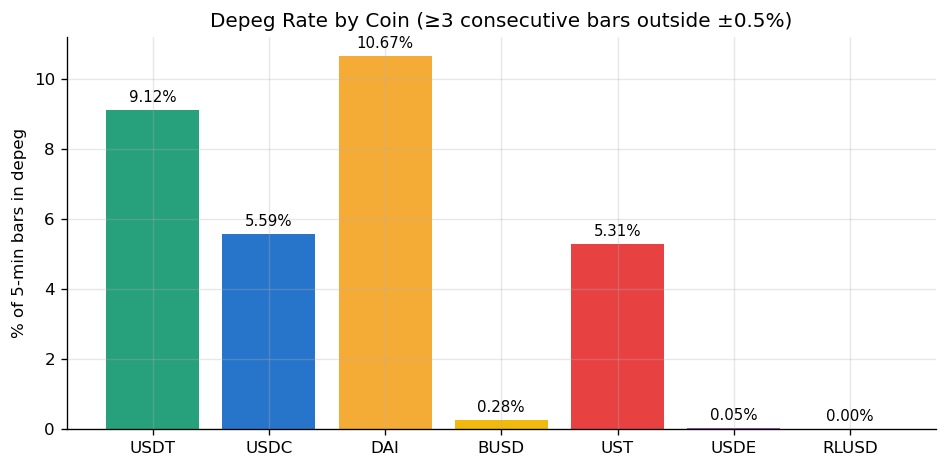

In [5]:
rates = {coin.upper(): dfs[coin]['depeg'].mean()*100 for coin in COINS}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(rates.keys(), rates.values(),
              color=[COLORS[c.lower()] for c in rates.keys()])
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_ylabel('% of 5-min bars in depeg')
ax.set_title('Depeg Rate by Coin (≥3 consecutive bars outside ±0.5%)')
plt.tight_layout()
plt.show()

## 4. Cross-Coin Depeg Correlation
Two views of how stablecoins relate to each other:
- **Price deviation correlation** — do coins move together in price pressure?
- **Depeg co-occurrence** — when coin A is depegged, how often is coin B also depegged?

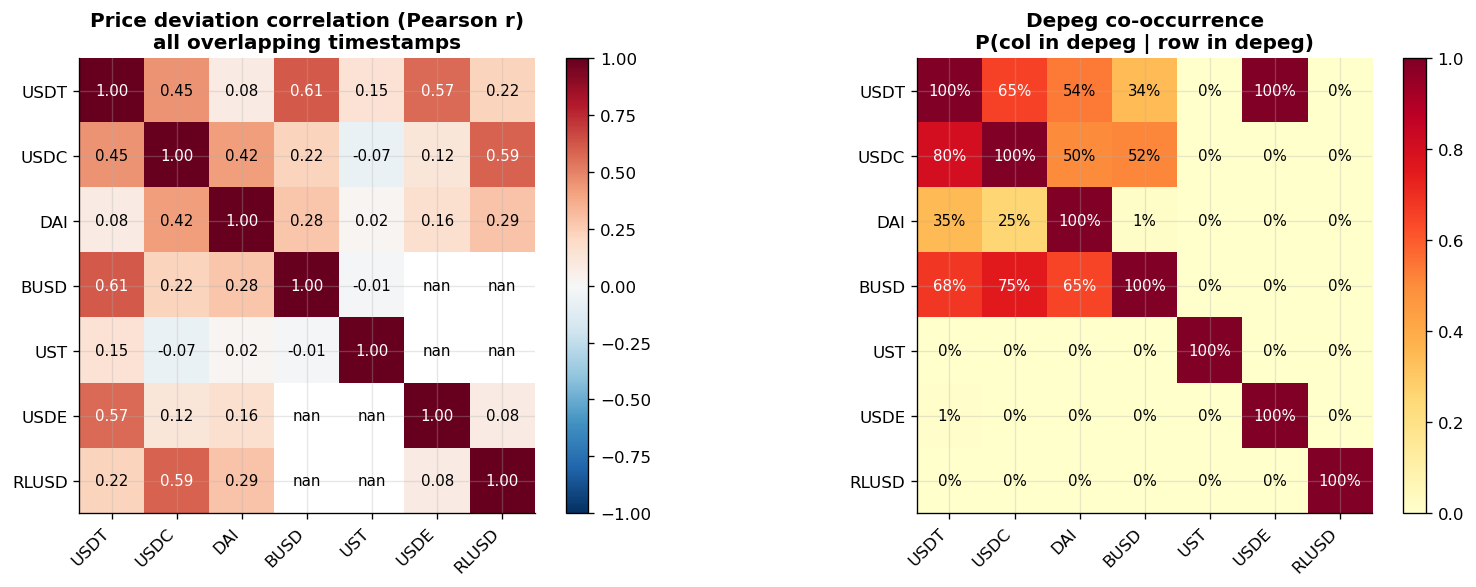

Notable co-occurrence (excluding diagonal, >5%):
  When USDT depegged → USDC also depegged 65% of the time
  When USDT depegged → DAI also depegged 54% of the time
  When USDT depegged → BUSD also depegged 34% of the time
  When USDT depegged → USDE also depegged 100% of the time
  When USDC depegged → USDT also depegged 80% of the time
  When USDC depegged → DAI also depegged 50% of the time
  When USDC depegged → BUSD also depegged 52% of the time
  When DAI depegged → USDT also depegged 35% of the time
  When DAI depegged → USDC also depegged 25% of the time
  When BUSD depegged → USDT also depegged 68% of the time
  When BUSD depegged → USDC also depegged 75% of the time
  When BUSD depegged → DAI also depegged 65% of the time


In [6]:
# ── Align price_dev and depeg across all coins on shared timestamps ───────────
pd_aligned  = pd.concat({c.upper(): dfs[c]['price_dev']                    for c in COINS}, axis=1)
dep_aligned = pd.concat({c.upper(): dfs[c]['depeg'].fillna(0).astype(float) for c in COINS}, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: price_dev Pearson correlation ───────────────────────────────────────
corr = pd_aligned.corr()
ax   = axes[0]
im   = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
n = len(corr)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.5 else 'black')
ax.set_title('Price deviation correlation (Pearson r)\nall overlapping timestamps', fontweight='bold')

# ── Right: depeg co-occurrence — P(col depegged | row depegged) ───────────────
coins_u = list(dep_aligned.columns)
cooccur = pd.DataFrame(index=coins_u, columns=coins_u, dtype=float)
for r in coins_u:
    for c in coins_u:
        if r == c:
            cooccur.loc[r, c] = 1.0
        else:
            pair = dep_aligned[[r, c]].dropna()
            n_r  = int((pair[r] == 1).sum())
            cooccur.loc[r, c] = float(((pair[r] == 1) & (pair[c] == 1)).sum()) / n_r if n_r > 0 else 0.0

ax2 = axes[1]
im2 = ax2.imshow(cooccur.values.astype(float), cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
m = len(coins_u)
ax2.set_xticks(range(m)); ax2.set_yticks(range(m))
ax2.set_xticklabels(coins_u, rotation=45, ha='right')
ax2.set_yticklabels(coins_u)
for i in range(m):
    for j in range(m):
        v = float(cooccur.iloc[i, j])
        ax2.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9,
                 color='white' if v > 0.6 else 'black')
ax2.set_title('Depeg co-occurrence\nP(col in depeg | row in depeg)', fontweight='bold')

plt.tight_layout()
plt.show()

# Notable pairs
print("Notable co-occurrence (excluding diagonal, >5%):")
for r in coins_u:
    for c in coins_u:
        v = float(cooccur.loc[r, c])
        if r != c and v > 0.05:
            print(f"  When {r} depegged → {c} also depegged {v:.0%} of the time")

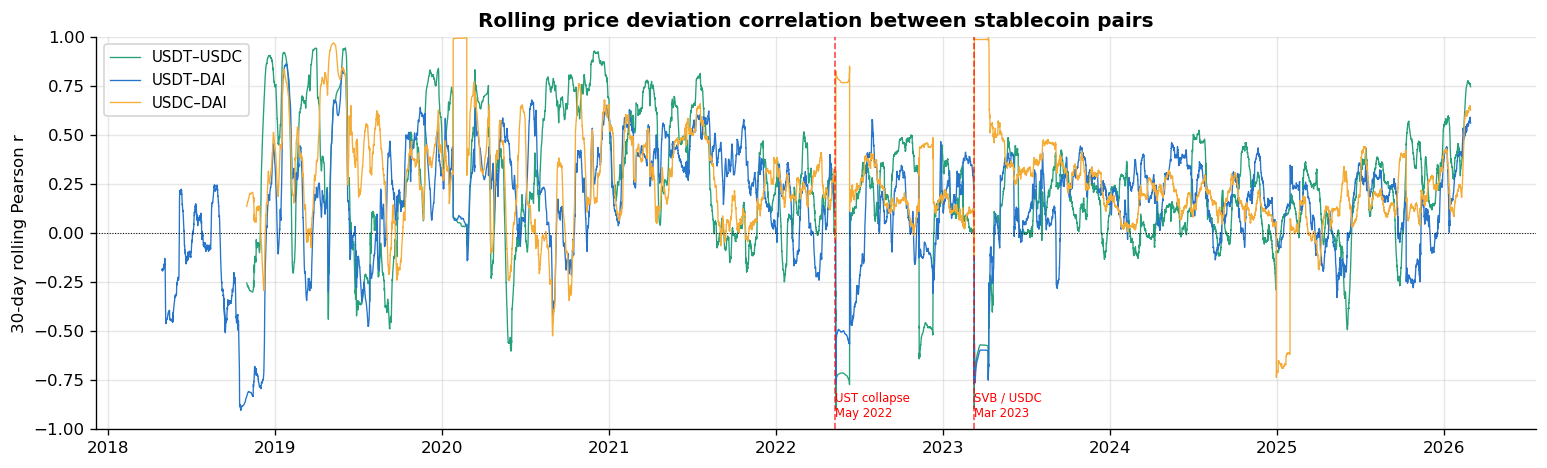

In [7]:
# ── Rolling 30-day correlation between key pairs ─────────────────────────────
PAIRS        = [('USDT', 'USDC'), ('USDT', 'DAI'), ('USDC', 'DAI')]
WINDOW       = 288 * 30   # 30 days in 5m bars
pair_colors  = ['#26A17B', '#2775CA', '#F5AC37']

fig, ax = plt.subplots(figsize=(13, 4))

for (a, b), color in zip(PAIRS, pair_colors):
    if a not in pd_aligned.columns or b not in pd_aligned.columns:
        continue
    roll_corr = pd_aligned[a].rolling(WINDOW, min_periods=WINDOW // 2).corr(pd_aligned[b])
    ax.plot(roll_corr.index, roll_corr, lw=0.8, label=f'{a}–{b}', color=color)

stress_events = {'UST collapse\nMay 2022': '2022-05-10', 'SVB / USDC\nMar 2023': '2023-03-10'}
for label, date in stress_events.items():
    ax.axvline(pd.Timestamp(date, tz='UTC'), color='red', lw=1, ls='--', alpha=0.7)
    ax.text(pd.Timestamp(date, tz='UTC'), -0.95, label, fontsize=7, color='red', va='bottom', ha='left')

ax.axhline(0, color='black', lw=0.6, ls=':')
ax.set_ylabel('30-day rolling Pearson r')
ax.set_title('Rolling price deviation correlation between stablecoin pairs', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

## 5. UST Collapse — May 2022

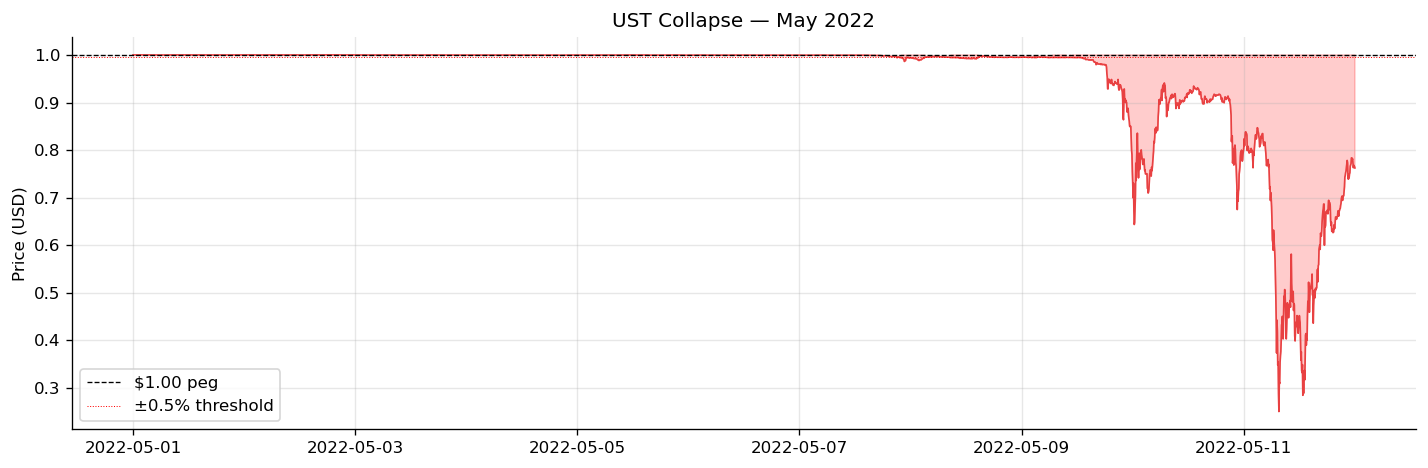

In [8]:
ust      = dfs['ust']
collapse = ust['2022-05-01':'2022-05-15']
depeg    = collapse['depeg'].fillna(0).astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(collapse.index, collapse['coinapi_close'], lw=1, color=COLORS['ust'])
ax.fill_between(collapse.index, collapse['coinapi_close'], 1,
                where=(depeg==1), color='red', alpha=0.2)
ax.axhline(1.0,   color='black', lw=0.8, ls='--', label='$1.00 peg')
ax.axhline(0.995, color='red',   lw=0.6, ls=':',  label='±0.5% threshold')
ax.set_title('UST Collapse — May 2022')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. On-chain Flows vs Price — USDT

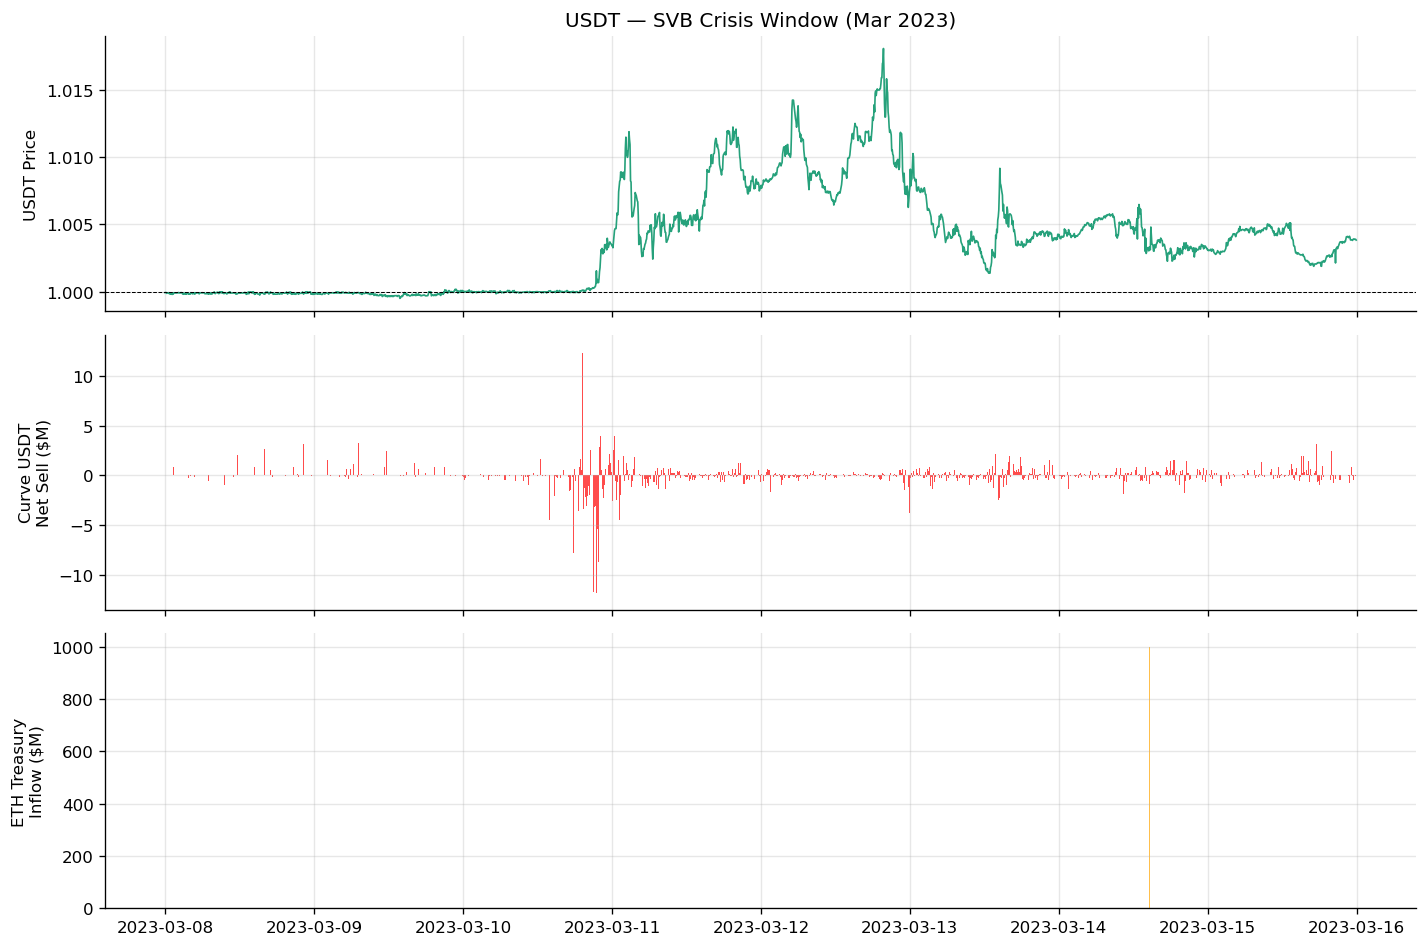

In [9]:
usdt = dfs['usdt'].copy()

# Focus on SVB crisis — USDC depeg Mar 2023
window = usdt['2023-03-08':'2023-03-15']

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax1.plot(window.index, window['coinapi_close'], lw=1, color=COLORS['usdt'])
ax1.axhline(1.0, color='black', lw=0.6, ls='--')
ax1.set_ylabel('USDT Price')
ax1.set_title('USDT — SVB Crisis Window (Mar 2023)')

ax2.bar(window.index, window['curve_3pool_usdt_net_sell_volume_usd']/1e6,
        width=0.003, color='red', alpha=0.7)
ax2.set_ylabel('Curve USDT\nNet Sell ($M)')

ax3.bar(window.index, window['treasury_inflow_volume_usd']/1e6,
        width=0.003, color='orange', alpha=0.7)
ax3.set_ylabel('ETH Treasury\nInflow ($M)')

plt.tight_layout()
plt.show()

## 7. USDC Depeg — SVB Crisis Mar 2023

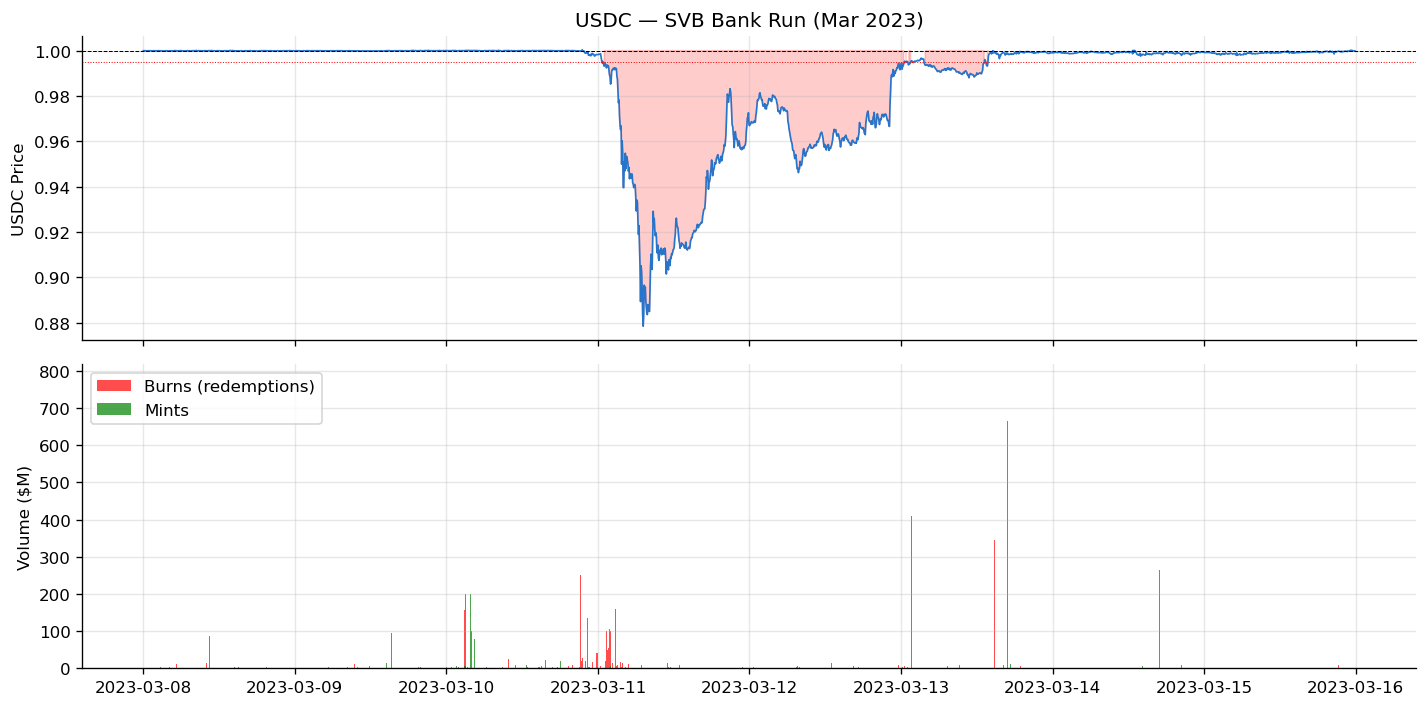

In [10]:
usdc  = dfs['usdc']
svb   = usdc['2023-03-08':'2023-03-15']
depeg = svb['depeg'].fillna(0).astype(float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(svb.index, svb['coinapi_close'], lw=1, color=COLORS['usdc'])
ax1.fill_between(svb.index, svb['coinapi_close'], 1,
                 where=(depeg==1), color='red', alpha=0.2)
ax1.axhline(1.0,   color='black', lw=0.6, ls='--')
ax1.axhline(0.995, color='red',   lw=0.6, ls=':')
ax1.set_ylabel('USDC Price')
ax1.set_title('USDC — SVB Bank Run (Mar 2023)')

ax2.bar(svb.index, svb['burn_volume_usd']/1e6, width=0.003,
        color='red', alpha=0.7, label='Burns (redemptions)')
ax2.bar(svb.index, svb['mint_volume_usd']/1e6, width=0.003,
        color='green', alpha=0.7, label='Mints')
ax2.set_ylabel('Volume ($M)')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Macro Correlation — VIX vs Depeg

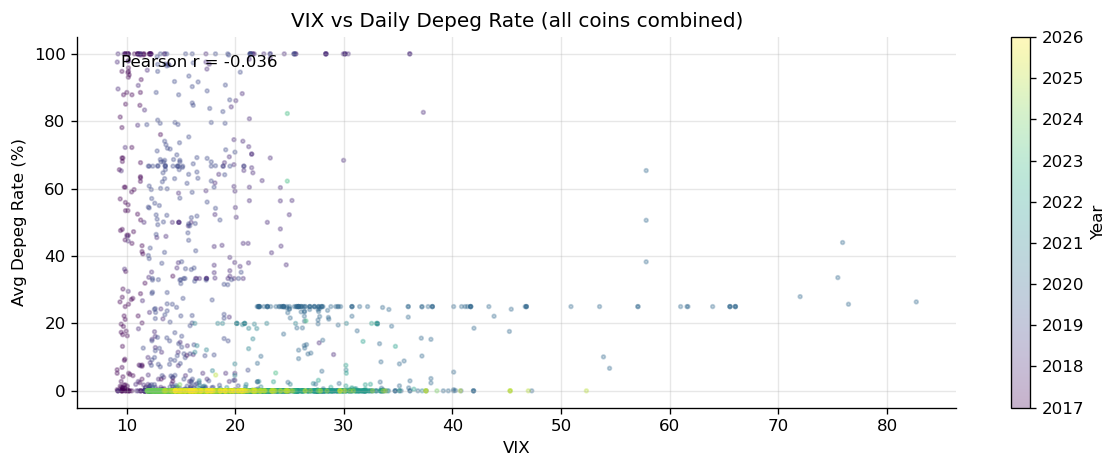

In [11]:
# Daily VIX vs daily depeg rate across all coins
all_dfs = []
for coin in COINS:
    df = dfs[coin][['vix', 'depeg']].copy()
    all_dfs.append(df)

combined = pd.concat(all_dfs).sort_index()
daily = combined.resample('1D').agg({'vix': 'first', 'depeg': 'mean'}).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(daily['vix'], daily['depeg']*100, alpha=0.3, s=5, c=daily.index.year, cmap='viridis')
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('VIX')
ax.set_ylabel('Avg Depeg Rate (%)')
ax.set_title('VIX vs Daily Depeg Rate (all coins combined)')
corr = daily[['vix','depeg']].corr().iloc[0,1]
ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.show()

## 9. Feature Missingness

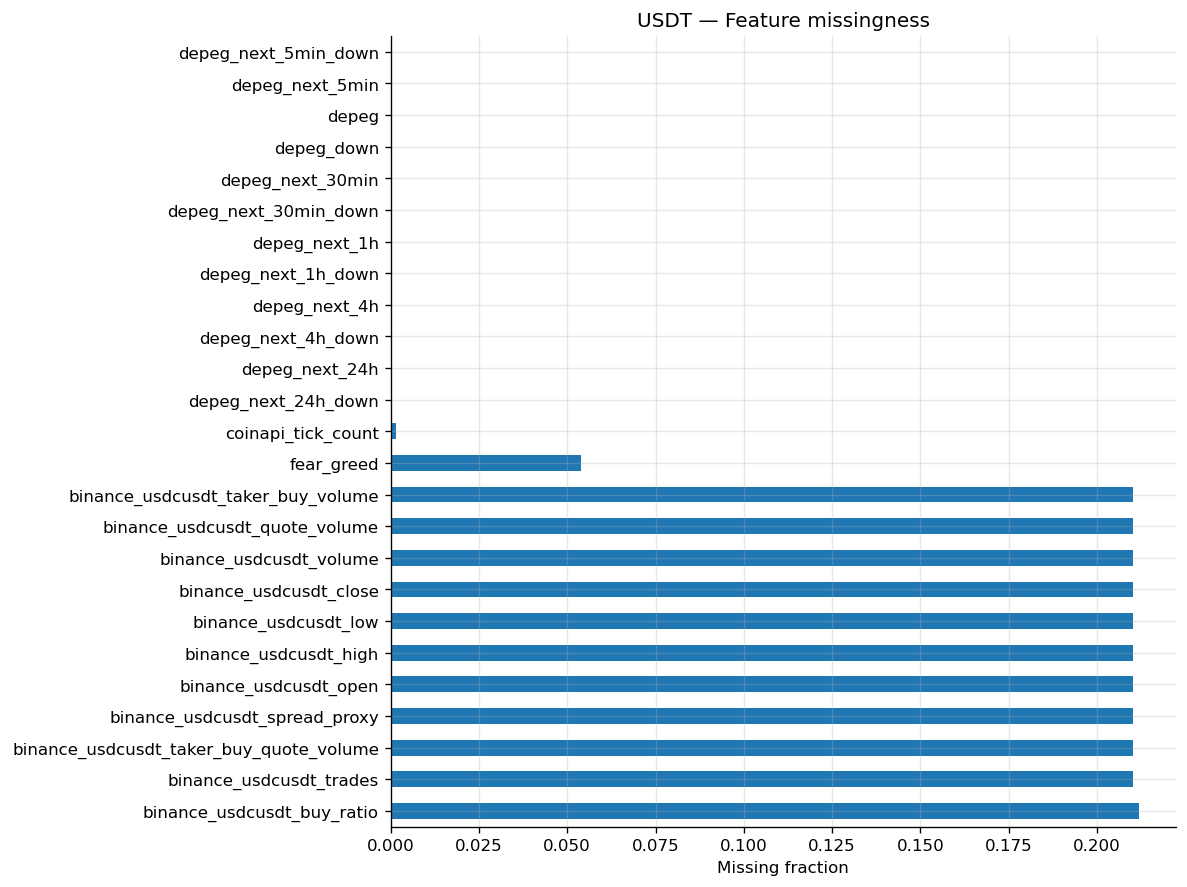

In [12]:
coin = 'usdt'
df   = dfs[coin]
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

if miss.empty:
    print('No missing values in', coin.upper())
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(miss)*0.3)))
    miss.plot.barh(ax=ax)
    ax.set_xlabel('Missing fraction')
    ax.set_title(f'{coin.upper()} — Feature missingness')
    plt.tight_layout()
    plt.show()

## 10. Label Distribution — Forward-looking Horizons

In [13]:
label_cols = ['depeg', 'depeg_next_5min', 'depeg_next_30min', 'depeg_next_1h', 'depeg_next_4h']

rows = []
for coin in COINS:
    df = dfs[coin]
    available = [c for c in label_cols if c in df.columns]
    row = {'Coin': coin.upper()}
    for col in available:
        row[col] = f"{df[col].mean():.2%}"
    rows.append(row)

pd.DataFrame(rows).set_index('Coin')

,depeg,depeg_next_5min,depeg_next_30min,depeg_next_1h,depeg_next_4h
Coin,,,,,
USDT,9.12%,9.12%,9.58%,9.92%,11.01%
USDC,5.59%,5.59%,5.78%,5.93%,6.44%
DAI,10.67%,10.67%,11.38%,11.89%,13.44%
BUSD,0.28%,0.28%,0.34%,0.38%,0.54%
UST,5.31%,5.31%,5.84%,6.19%,7.36%
USDE,0.05%,0.05%,0.08%,0.10%,0.19%
RLUSD,0.00%,0.00%,0.00%,0.00%,0.00%


## 11. On-chain & Curve Flows as Leading Indicators
Do institutional flows precede depegs — and at what timescale?

Two charts per coin:
- **Signal ratio by horizon** — how much higher is the rolling 1h flow at onset rows vs stable rows, across 4 depeg prediction horizons (5min, 30min, 1h, 4h). A ratio > 1 means the signal is elevated before depegs.
- **Lead time curves** — for the top signals, how does that elevation change as we look further back before a depeg onset? Peaks early → very short-leading; stays elevated → longer warning window.

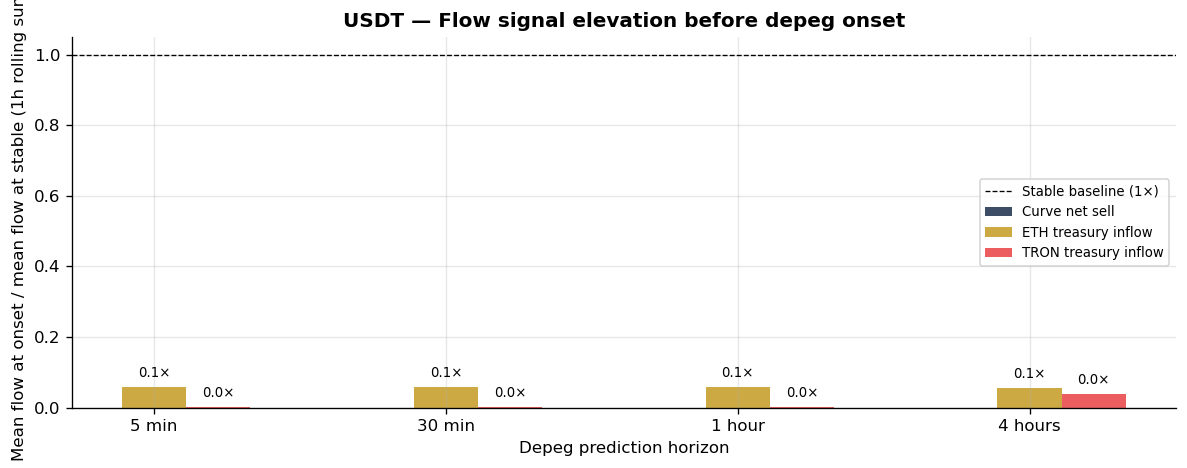

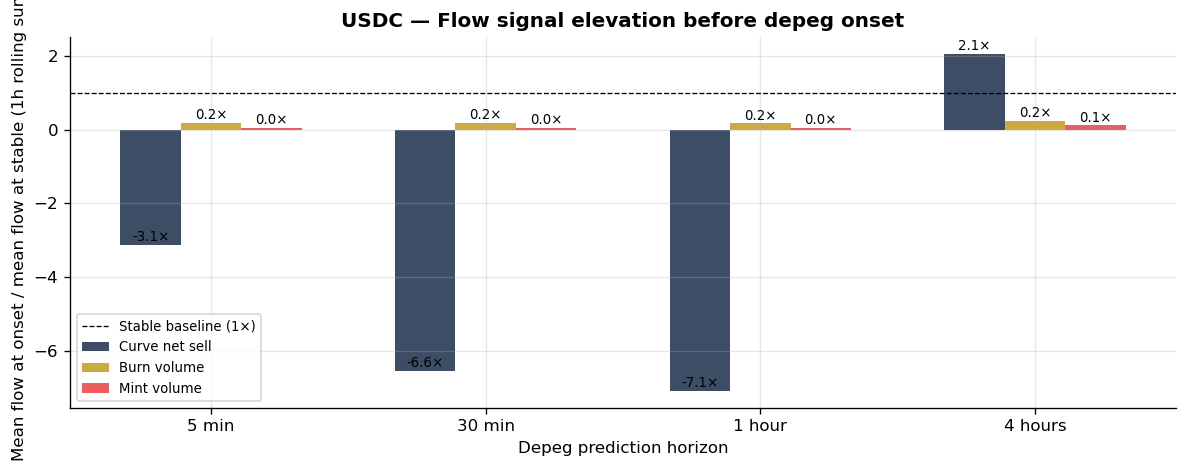

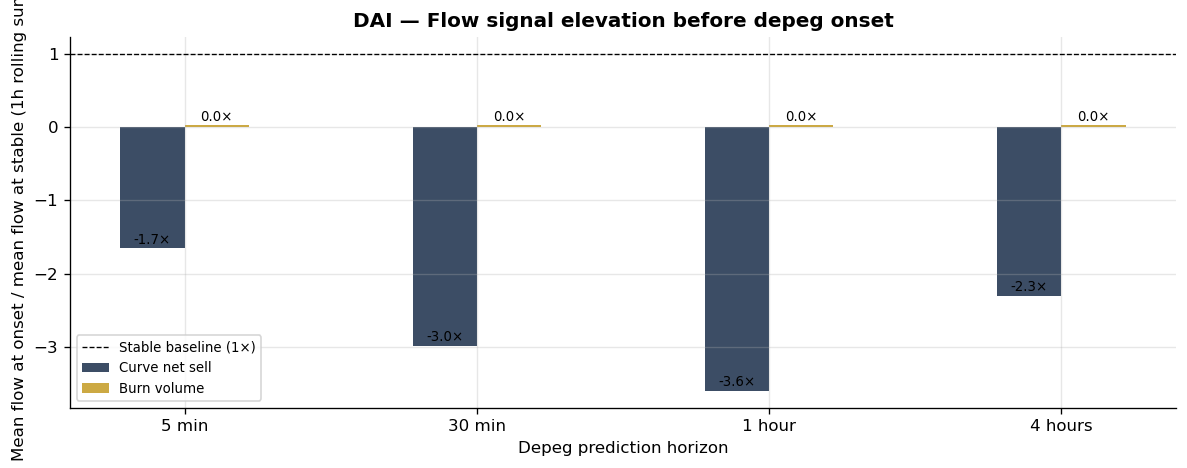

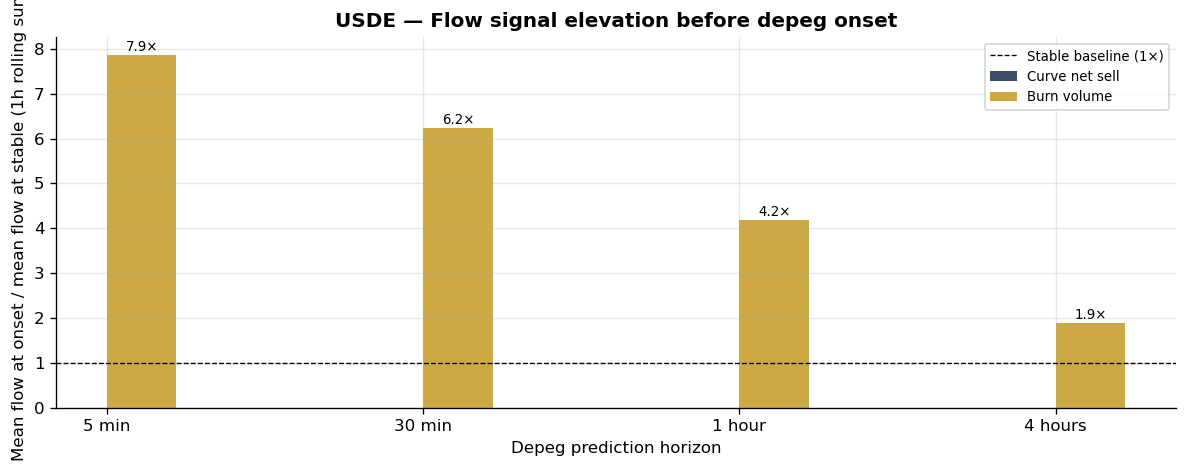

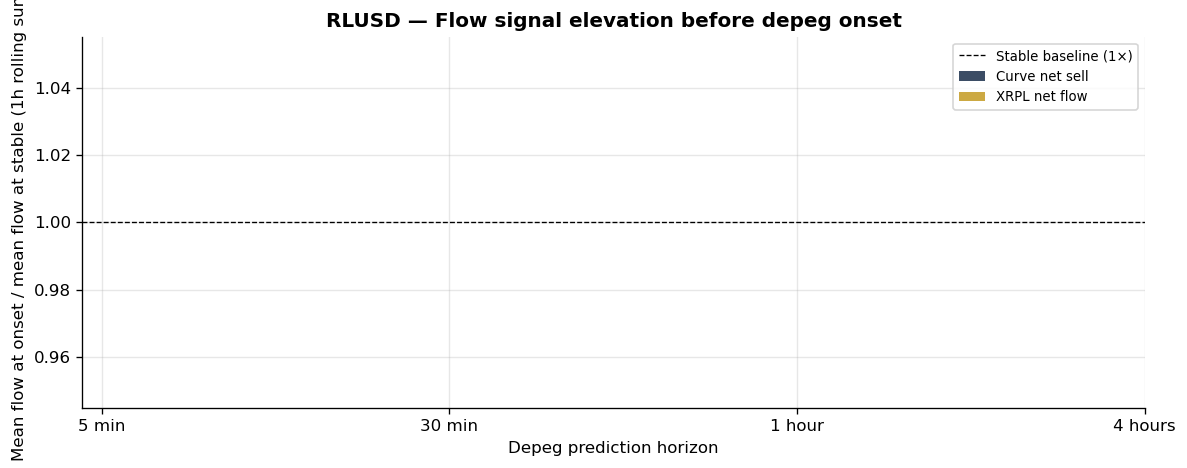

In [14]:
BARS_1H  = 12   # 5-min bars per hour
HORIZONS = [
    ("depeg_next_5min",  "5 min"),
    ("depeg_next_30min", "30 min"),
    ("depeg_next_1h",    "1 hour"),
    ("depeg_next_4h",    "4 hours"),
]

# Signals to evaluate per coin: (column, display label)
COIN_SIGNALS = {
    "usdt": [
        ("curve_3pool_usdt_net_sell_volume_usd", "Curve net sell"),
        ("treasury_inflow_volume_usd",           "ETH treasury inflow"),
        ("tron_treasury_inflow_volume_usd",      "TRON treasury inflow"),
    ],
    "usdc": [
        ("curve_3pool_usdc_net_sell_volume_usd", "Curve net sell"),
        ("burn_volume_usd",                      "Burn volume"),
        ("mint_volume_usd",                      "Mint volume"),
    ],
    "dai": [
        ("curve_3pool_dai_net_sell_volume_usd",  "Curve net sell"),
        ("burn_volume_usd",                      "Burn volume"),
    ],
    "usde": [
        ("curve_usde_usdc_usde_net_sell_volume_usd", "Curve net sell"),
        ("burn_volume_usd",                          "Burn volume"),
    ],
    "rlusd": [
        ("curve_rlusd_usdc_rlusd_net_sell_volume_usd", "Curve net sell"),
        ("xrpl_net_flow_usd",                          "XRPL net flow"),
    ],
}

x = np.arange(len(HORIZONS))
bar_w = 0.22

for coin, signals in COIN_SIGNALS.items():
    df = dfs[coin].copy()
    avail = [(col, lbl) for col, lbl in signals if col in df.columns]
    if not avail:
        continue

    rolled = {lbl: df[col].rolling(BARS_1H, min_periods=1).sum() for col, lbl in avail}
    stable_mask = df["depeg"].fillna(0) == 0

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#1A2E4A", "#C49A22", "#E84142"]

    for k, (lbl, color) in enumerate(zip(rolled, colors)):
        ratios = []
        for h_col, h_label in HORIZONS:
            if h_col not in df.columns:
                ratios.append(float("nan"))
                continue
            h = df[h_col].astype(float)
            onset  = rolled[lbl][stable_mask & (h == 1)]
            stable = rolled[lbl][stable_mask & (h == 0)]
            stable_mean = stable.mean()
            ratios.append(onset.mean() / stable_mean if stable_mean > 0 else float("nan"))

        offset = (k - len(avail) / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, ratios, bar_w, label=lbl, color=color, alpha=0.85)
        for bar, v in zip(bars, ratios):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f"{v:.1f}\u00d7", ha="center", va="bottom", fontsize=8)

    ax.axhline(1, color="black", lw=0.8, ls="--", label="Stable baseline (1\u00d7)")
    ax.set_xticks(x)
    ax.set_xticklabels([h for _, h in HORIZONS])
    ax.set_xlabel("Depeg prediction horizon")
    ax.set_ylabel("Mean flow at onset / mean flow at stable (1h rolling sum)")
    ax.set_title(f"{coin.upper()} \u2014 Flow signal elevation before depeg onset", fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

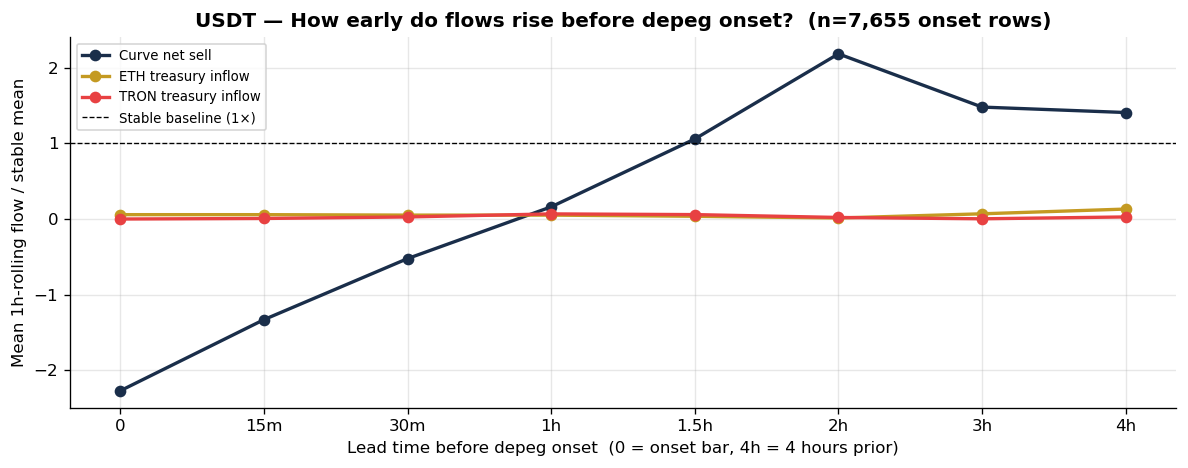

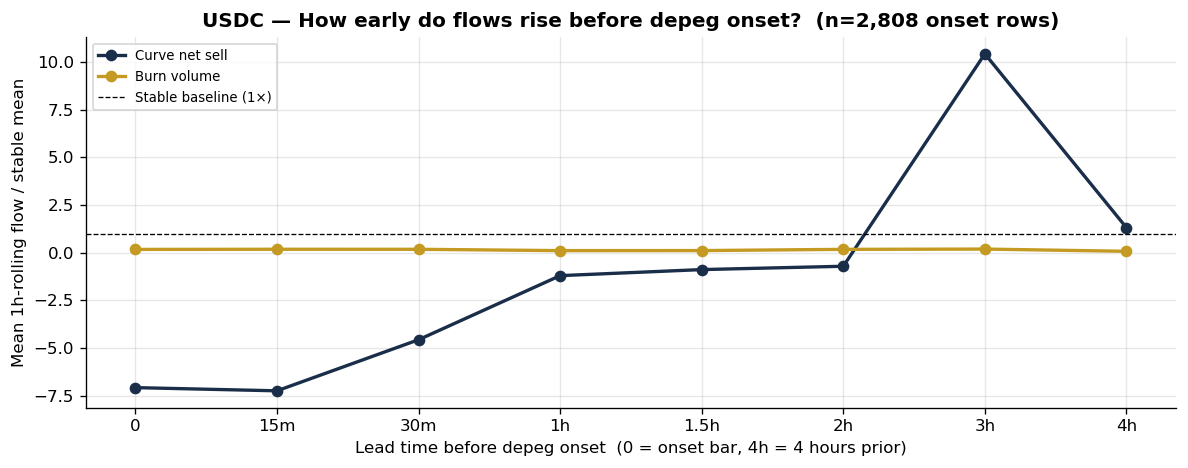

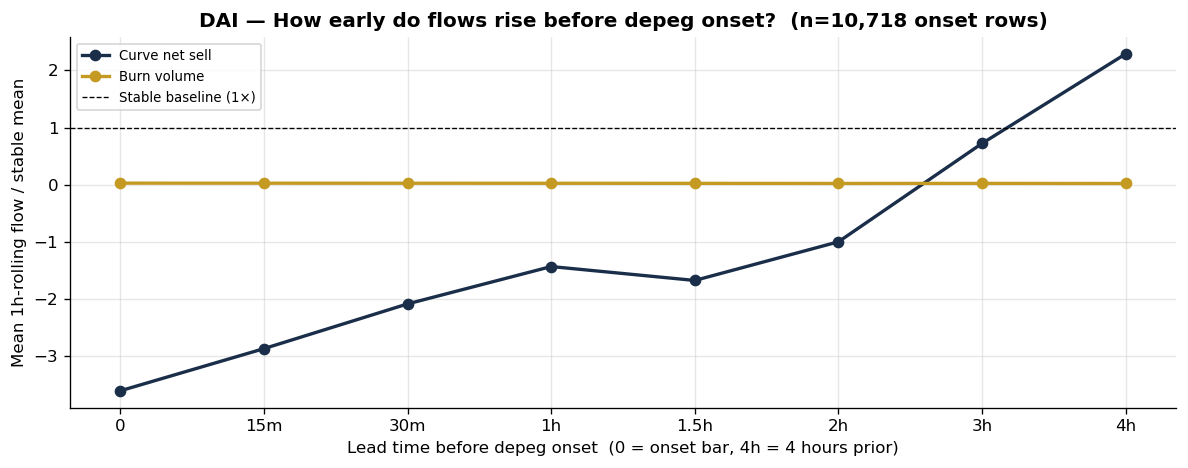

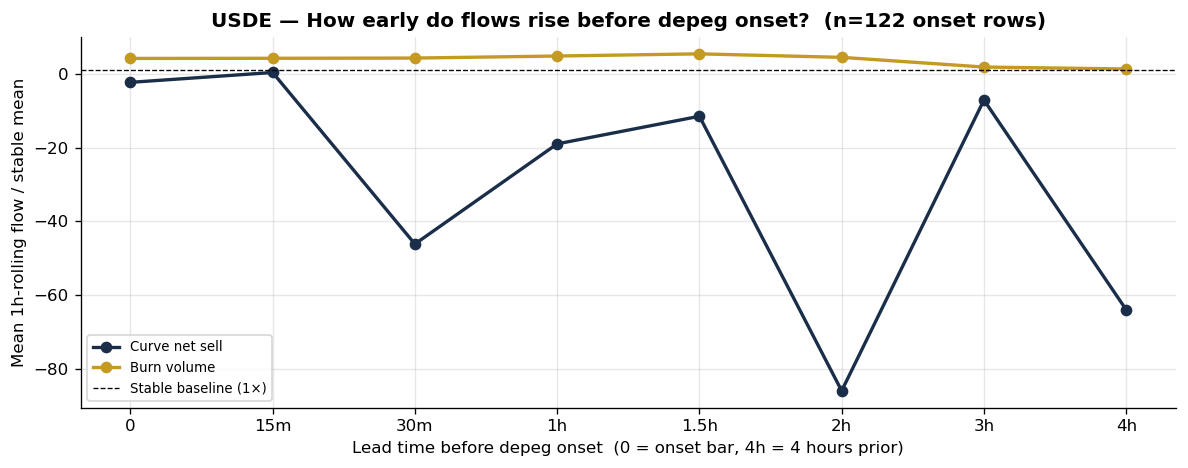

RLUSD: only 0 onset rows — skipping lead time chart
Interpretation guide:
  ratio >> 1 at large lead time  → long early-warning window
  ratio >> 1 only at 0–15min     → very short-leading, near-coincident with depeg
  ratio ≈ 1 throughout            → signal not predictive at 1h rolling resolution


In [15]:
# Lead time curves — how far in advance does each signal start rising?
# For each lead k bars (0 = onset bar, 12 = 1h before, 48 = 4h before),
# compute mean signal at stable rows whose depeg_next_1h fires k bars later.
LEAD_BARS   = [0, 3, 6, 12, 18, 24, 36, 48]   # 0, 15m, 30m, 1h, 1.5h, 2h, 3h, 4h
LEAD_LABELS = ["0", "15m", "30m", "1h", "1.5h", "2h", "3h", "4h"]

LEAD_SIGNALS = {
    "usdt": [
        ("curve_3pool_usdt_net_sell_volume_usd", "Curve net sell",       "#1A2E4A"),
        ("treasury_inflow_volume_usd",           "ETH treasury inflow",  "#C49A22"),
        ("tron_treasury_inflow_volume_usd",      "TRON treasury inflow", "#E84142"),
    ],
    "usdc": [
        ("curve_3pool_usdc_net_sell_volume_usd", "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                      "Burn volume",    "#C49A22"),
    ],
    "dai": [
        ("curve_3pool_dai_net_sell_volume_usd",  "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                      "Burn volume",    "#C49A22"),
    ],
    "usde": [
        ("curve_usde_usdc_usde_net_sell_volume_usd", "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                          "Burn volume",    "#C49A22"),
    ],
    "rlusd": [
        ("curve_rlusd_usdc_rlusd_net_sell_volume_usd", "Curve net sell",  "#1A2E4A"),
        ("xrpl_net_flow_usd",                          "XRPL net flow",   "#C49A22"),
    ],
}

for coin, signals in LEAD_SIGNALS.items():
    df = dfs[coin].copy()
    onset_mask  = (df["depeg"].fillna(0) == 0) & (df["depeg_next_1h"].fillna(0).astype(float) == 1)
    stable_mask = (df["depeg"].fillna(0) == 0) & (df["depeg_next_1h"].fillna(0).astype(float) == 0)

    n_onset = onset_mask.sum()
    if n_onset < 50:
        print(f"{coin.upper()}: only {n_onset} onset rows — skipping lead time chart")
        continue

    fig, ax = plt.subplots(figsize=(10, 4))
    plotted = 0

    for col, lbl, color in signals:
        if col not in df.columns:
            continue
        signal = df[col].rolling(BARS_1H, min_periods=1).sum()
        stable_mean = signal[stable_mask].mean()
        if stable_mean == 0:
            continue

        ratios = []
        for k in LEAD_BARS:
            shifted = signal.shift(k)
            ratios.append(shifted[onset_mask].mean() / stable_mean)

        ax.plot(range(len(LEAD_BARS)), ratios, "o-", label=lbl, color=color, lw=2, ms=6)
        plotted += 1

    if plotted == 0:
        plt.close()
        print(f"{coin.upper()}: no valid signals found — skipping")
        continue

    ax.axhline(1, color="black", lw=0.8, ls="--", label="Stable baseline (1×)")
    ax.set_xticks(range(len(LEAD_BARS)))
    ax.set_xticklabels(LEAD_LABELS)
    ax.set_xlabel("Lead time before depeg onset  (0 = onset bar, 4h = 4 hours prior)")
    ax.set_ylabel("Mean 1h-rolling flow / stable mean")
    ax.set_title(f"{coin.upper()} — How early do flows rise before depeg onset?  (n={n_onset:,} onset rows)", fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print("Interpretation guide:")
print("  ratio >> 1 at large lead time  → long early-warning window")
print("  ratio >> 1 only at 0–15min     → very short-leading, near-coincident with depeg")
print("  ratio ≈ 1 throughout            → signal not predictive at 1h rolling resolution")

## 12. Next Step
Run `04_feature_engineering.ipynb` to build rolling-window features per coin, then `05_build_pooled_dataset.ipynb` to stack all coins, and finally `06_eda_features.ipynb` for modeling-level EDA.